# Introduction to Neural Networks

A simple explanation of how they work and how to implement one from scratch in Python.

Here’s something that might surprise you: neural networks aren’t that complicated! The term “neural network” gets used as a buzzword a lot, but in reality they’re often much simpler than people imagine.

Lot of materiels were taken from: https://victorzhou.com/blog/intro-to-neural-networks/

## WHAT is a Neural Network?
The neural networks that we are going to considered are strictly called artificial neural networks, and as the name suggests, are based on what science knows about the human brain’s structure and function.
Briefly, a neural network is defined as a computing system that consist of a number of simple but highly interconnected elements or nodes, called ‘neurons’, which are organized in layers which process information using dynamic state responses to external inputs. This algorithm is extremely useful, as we will explain later, in finding patterns that are too complex for being manually extracted and taught to recognize to the machine. In the context of this structure, patterns are introduced to the neural network by the input layer that has one neuron for each component present in the input data and is communicated to one or more hidden layers present in the network; called ‘hidden’ only due to the fact that they do not constitute the input or output layer. It is in the hidden layers where all the processing actually happens through a system of connections characterized by weights and biases (commonly referred as W and b): the input is received, the neuron calculate a weighted sum adding also the bias and according to the result and a pre-set activation function (most common one is sigmoid, σ, even though it almost not used anymore and there are better ones like ReLu), it decides whether it should be ‘fired’ or activated. Afterwards, the neuron transmit the information downstream to other connected neurons in a process called ‘forward pass’. At the end of this process, the last hidden layer is linked to the output layer which has one neuron for each possible desired output.

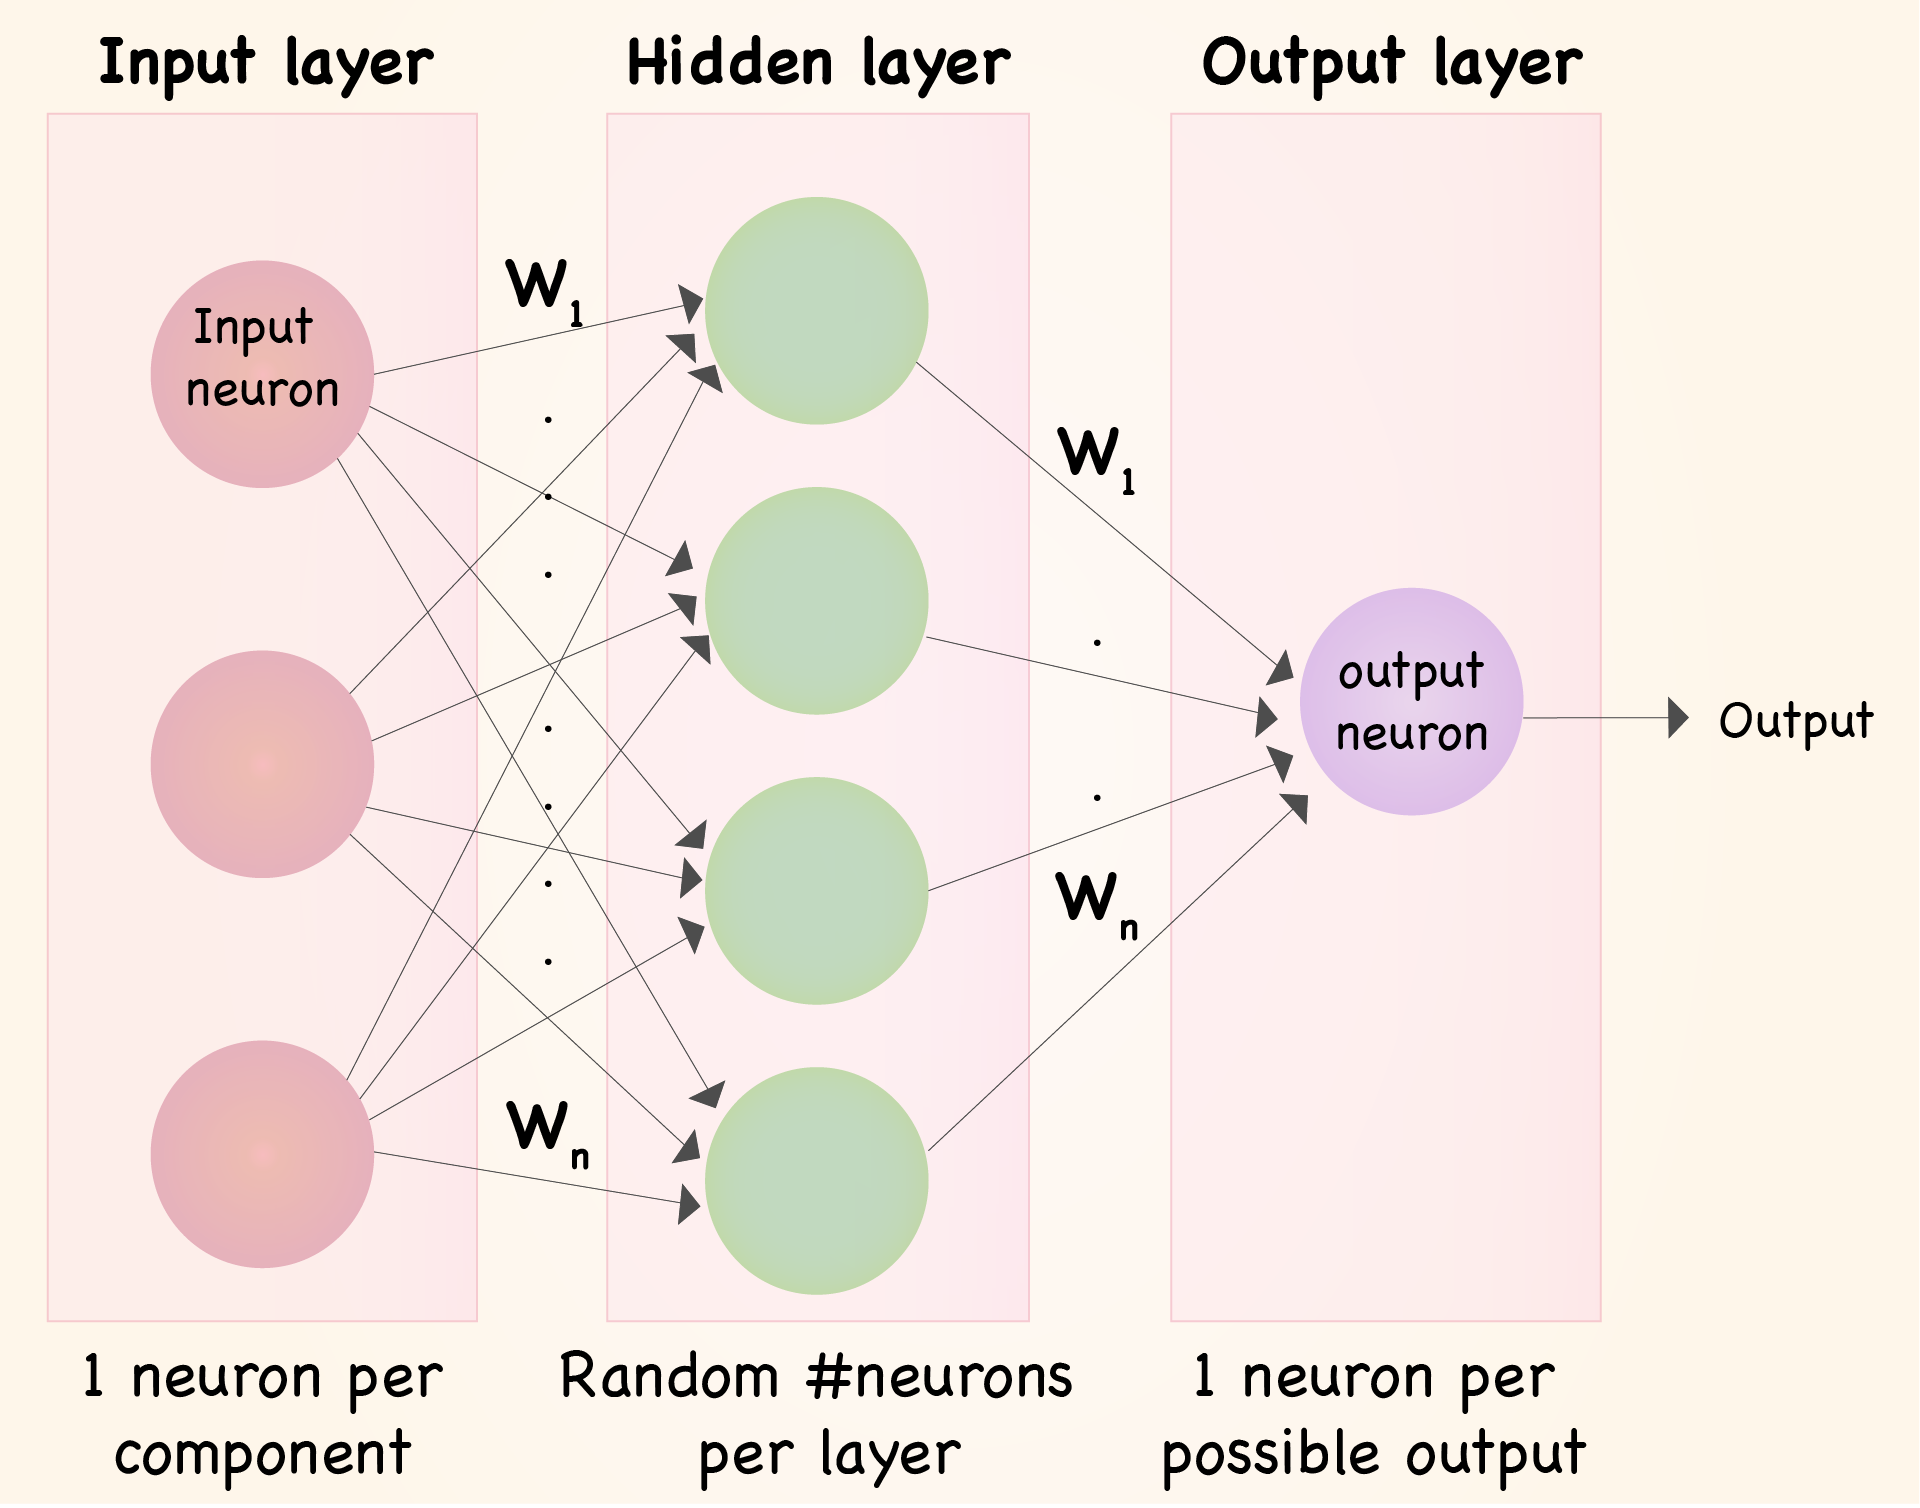

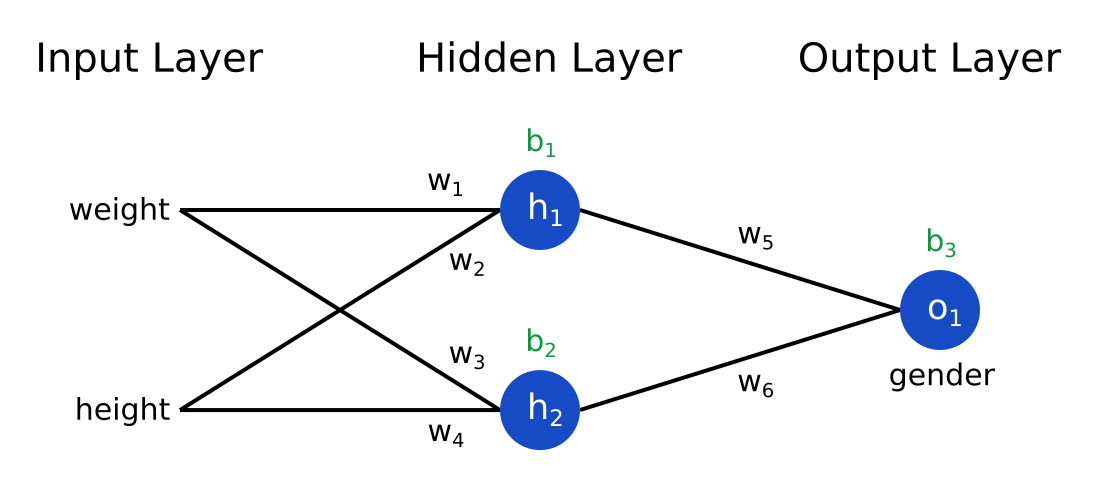

## Building Blocks: Neurons
First, we have to talk about neurons, the basic unit of a neural network. A neuron takes inputs, does some math with them, and produces one output. Here’s what a 2-input neuron looks like:
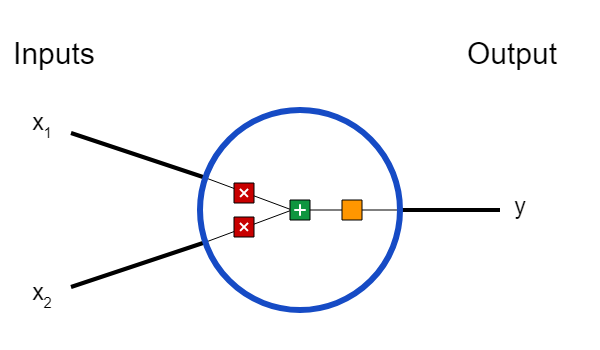
3 things are happening here. First, each input is multiplied by a weight:
each input is multiplied by a weight (1) and added toegther with a bias (3):

$(x_1*w_q) + (x_2*w_2) + b$

(3) third the sum is passed through an activation function:

$y = f((x_1*w_q) + (x_2*w_2) + b)$

The activation function is used to turn an unbounded input into an output that has a nice, predictable form. A commonly used activation function is the sigmoid function:
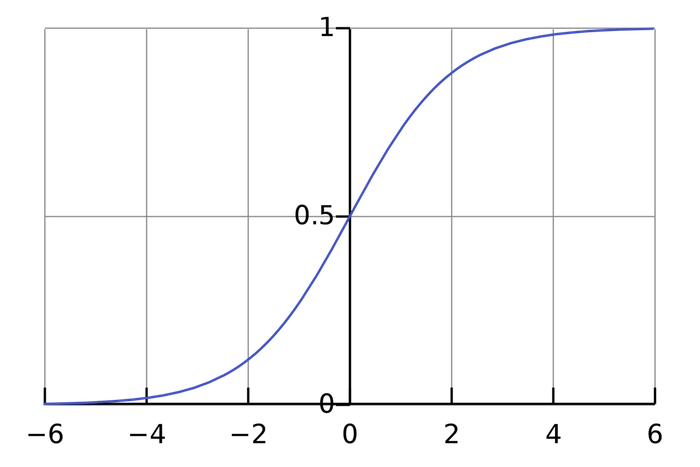

The sigmoid function only outputs numbers in the range (0, 1)(0,1). You can think of it as compressing (-$\infty$, +$\infty$)to (0, 1)(0,1) - big negative numbers become ~0, and big positive numbers become ~1.

## A Simple Example:
Assume we have a 2-input neuron that uses the sigmoid activation function and has the following parameters:
```
w=[0,1]
b = 4
```
```w=[0,1]``` is just a wat of writting $w_1$=0, $w_2$=1 in vector form. Now  let’s give the neuron an input of ```x = [2, 3]```. We’ll use the dot product to write things more concisely:

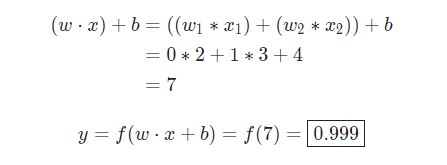

The neuron outputs 0.9990.999 given the inputs x = [2, 3]x=[2,3]. That’s it! This process of passing inputs forward to get an output is known as **feedforward**.

## 1. Coding a Neuron
Time to implement a neuron! We’ll use NumPy, a popular and powerful computing library for Python, to help us do math:

In [2]:
import numpy as np

def sigmoid(x):
  # Our activation function: f(x) = 1 / (1 + e^(-x))
  return 1 / (1 + np.exp(-x))

class Neuron:
  def __init__(self, weights, bias):
    self.weights = weights
    self.bias = bias

  def feedforward(self, inputs):
    # Weight inputs, add bias, then use the activation function
    total = np.dot(self.weights, inputs) + self.bias
    return sigmoid(total)

weights = np.array([0, 1, 0]) # w1 = 0, w2 = 1
bias = 4                   # b = 4
n = Neuron(weights, bias)

x = np.array([2, 3, 1])       # x1 = 2, x2 = 3
print(n.feedforward(x))    # 0.9990889488055994

0.9990889488055994


## 2. Combining Neurons into a Neural Network
A neural network is nothing more than a bunch of neurons connected together. Here’s what a simple neural network might look like:

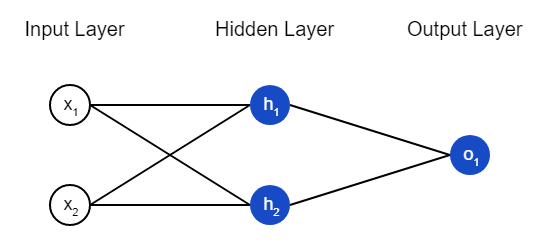

This network has 2 inputs, a hidden layer with 2 neurons ($h_1$ and $h_2$), and an output layer with 1 neuron ($o_1$). Notice that the inputs for $o_1$ are the outputs from $h_1$ and $h_2$ that’s what makes this a network.

A **hidden layer** is any layer between the input (first) layer and output (last) layer. There can be multiple hidden layers!

Let’s use the network pictured above and assume all neurons have the same weights w = [0, 1]w=[0,1], the same bias b = 0b=0, and the same sigmoid activation function. Let $h_1$, $h_2$ and $o_1$ denote the outputs of the neurons they represent.

What happens if we pass in the input ```x = [2, 3]```?
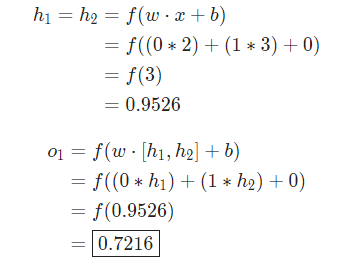
The output of the neural network for input ```x = [2, 3]``` is 0.72160.7216. Pretty simple, right?

A neural network can have any number of layers with any number of neurons in those layers. The basic idea stays the same: feed the input(s) forward through the neurons in the network to get the output(s) at the end. For simplicity, we’ll keep using the network pictured above for the rest of this post.

### Coding a Neural Network: Feedforward
Let’s implement feedforward for our neural network. Here’s the image of the network again for reference:
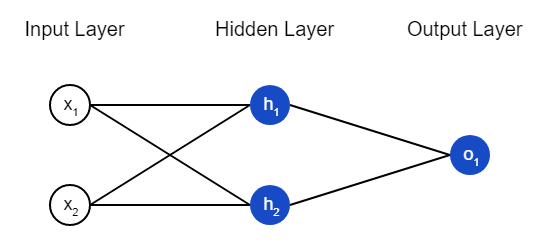

In [2]:
import numpy as np

# ... code from previous section here

class OurNeuralNetwork:
  '''
  A neural network with:
    - 2 inputs
    - a hidden layer with 2 neurons (h1, h2)
    - an output layer with 1 neuron (o1)
  Each neuron has the same weights and bias:
    - w = [0, 1]
    - b = 0
  '''
  def __init__(self):
    weights = np.array([0, 1])
    bias = 0

    # The Neuron class here is from the previous section
    self.h1 = Neuron(weights, bias)
    self.h2 = Neuron(weights, bias)
    self.o1 = Neuron(weights, bias)

  def feedforward(self, x):
    out_h1 = self.h1.feedforward(x)
    out_h2 = self.h2.feedforward(x)

    # The inputs for o1 are the outputs from h1 and h2
    out_o1 = self.o1.feedforward(np.array([out_h1, out_h2]))

    return out_o1

network = OurNeuralNetwork()
x = np.array([2, 3])
print(network.feedforward(x)) # 0.7216325609518421

0.7216325609518421


## 3. Training a Neural Network, Part 1

Say we have the following measurements:
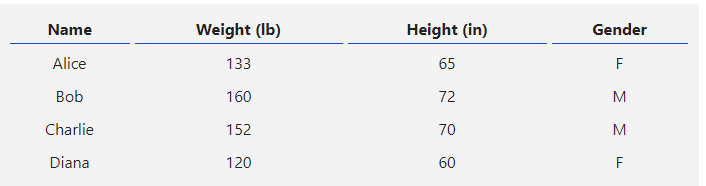

Let’s train our network to predict someone’s gender given their weight and height:
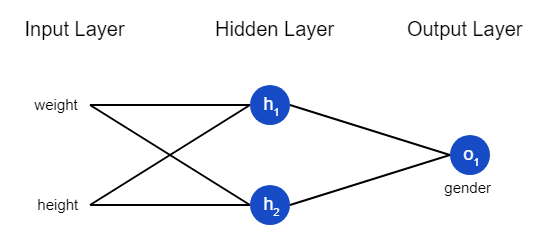
We’ll represent Male with a 00 and Female with a 11, and we’ll also shift the data to make it easier to use:
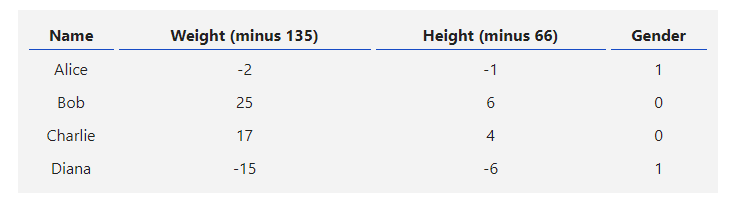
**Pre-processing**: arbitrarily chose the shift amounts (135135 and 6666) to make the numbers look nice. Normally, you’d shift by the mean.

### Loss function:
Before we train our network, we first need a way to quantify how “good” it’s doing so that it can try to do “better”. That’s what the loss is.

We’ll use the mean squared error (MSE) loss:

$\text{MSE} = \frac{1}{n} \sum_{i=1}^n (y_{true} - y_{pred})^2$

 
Let’s break this down:

1. n is the number of samples, which is 4 (Alice, Bob, Charlie, Diana).
2. y represents the variable being predicted, which is Gender.
3. $y_{true}$ is the true value of the variable (the “correct answer”). For example, $y_{true}$ for Alice would be 1 (Female).
4. $y_{pred}$ is the predicted value of the variable. It’s whatever our network outputs.

$(y_{true} - y_{pred})^2$ is known as the squared error. Our loss function is simply taking the average over all squared errors (hence the name mean squared error). The better our predictions are, the lower our loss will be!

Better predictions = Lower loss.

**Training a network = trying to minimize its loss.**

## An Example Loss Calculation
Let’s say our network always outputs 0 - in other words, it’s confident all humans are Male 🤔. What would our loss be?

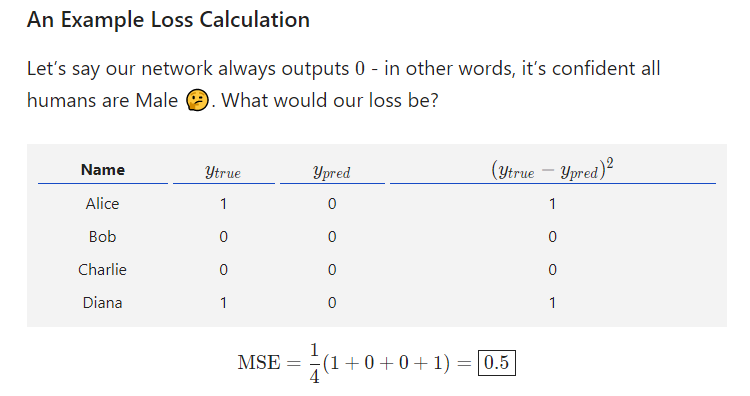

**Code: MSE Loss**
Here’s some code to calculate loss for us:

In [3]:
import numpy as np

def mse_loss(y_true, y_pred):
  # y_true and y_pred are numpy arrays of the same length.
  return ((y_true - y_pred) ** 2).mean()

y_true = np.array([1, 0, 0, 1])
y_pred = np.array([0, 0, 0, 0])

print(mse_loss(y_true, y_pred)) # 0.5

0.5


## 4. Training a Neural Network, Part 2
We now have a clear goal: minimize the loss of the neural network. We know we can change the network’s weights and biases to influence its predictions, but how do we do so in a way that decreases loss?

For simplicity, let’s pretend we only have Alice in our dataset:
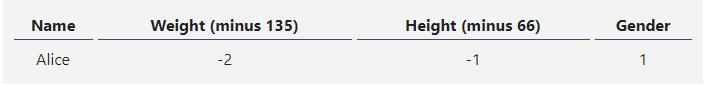
Then the mean squared error loss is just Alice’s squared error:
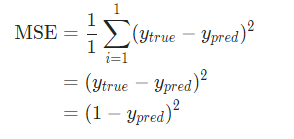

Another way to think about loss is as a function of weights and biases. Let’s label each weight and bias in our network:

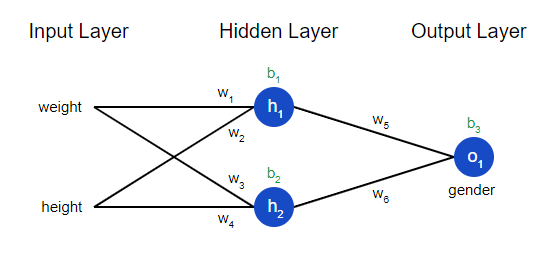

Then, we can write loss as a multivariable function:

```L(w_1, w_2, w_3, w_4, w_5, w_6, b_1, b_2, b_3)```

Imagine we wanted to tweak $w_1$. How would loss L change if we changed $w_1$? That’s a question the partial derivative $\frac{\partial L}{\partial w_1}$ can answer:
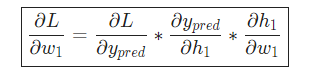
This system of calculating partial derivatives by working backwards is known as **backpropagation**.
Let's take Alice's data:
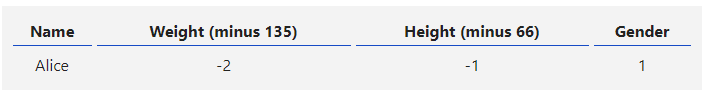

Let’s initialize all the weights to 11 and all the biases to 00. If we do a feedforward pass through the network, we get:
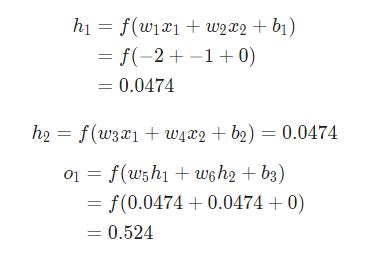
The network outputs $y_{pred}$ = 0.524, which doesn’t strongly favor Male (0) or Female (1). Let’s calculate $\frac{\partial L}{\partial w_1}$:
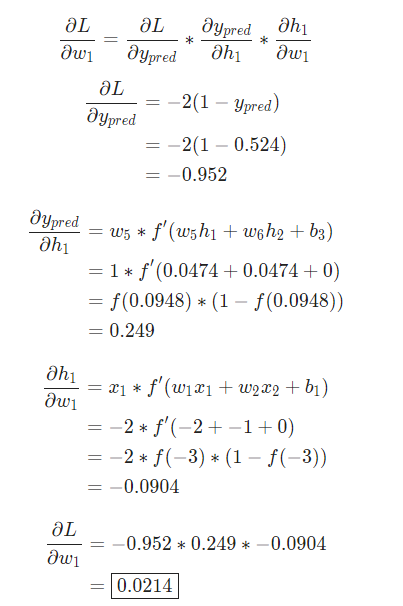

## Training: Stochastic Gradient Descent
We have all the tools we need to train a neural network now! We’ll use an optimization algorithm called stochastic gradient descent (SGD) that tells us how to change our weights and biases to minimize loss. It’s basically just this update equation:
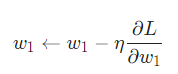
$\eta$ is a constant called the learning rate that controls how fast we train. All we’re doing is subtracting $\eta$ $\frac{\partial L}{\partial w_1}$ from $w_1$

If we do this for every weight and bias in the network, the loss will slowly decrease and our network will improve.

Our training process will look like this:

1. Choose one sample from our dataset. This is what makes it stochastic gradient descent - we only operate on one sample at a time.
2. Calculate all the partial derivatives of loss with respect to weights or biases (e.g. $\frac{\partial L}{\partial w_1}$, $\frac{\partial L}{\partial w_2}$, etc).
3. Use the update equation to update each weight and bias.
4. Go back to step 1.


In [4]:
### Code: A Complete Neural Network
import numpy as np

def sigmoid(x):
  # Sigmoid activation function: f(x) = 1 / (1 + e^(-x))
  return 1 / (1 + np.exp(-x))

def deriv_sigmoid(x):
  # Derivative of sigmoid: f'(x) = f(x) * (1 - f(x))
  fx = sigmoid(x)
  return fx * (1 - fx)

def mse_loss(y_true, y_pred):
  # y_true and y_pred are numpy arrays of the same length.
  return ((y_true - y_pred) ** 2).mean()

class OurNeuralNetwork:
  '''
  A neural network with:
    - 2 inputs
    - a hidden layer with 2 neurons (h1, h2)
    - an output layer with 1 neuron (o1)

  *** DISCLAIMER ***:
  The code below is intended to be simple and educational, NOT optimal.
  Real neural net code looks nothing like this. DO NOT use this code.
  Instead, read/run it to understand how this specific network works.
  '''
  def __init__(self):
    # Weights
    self.w1 = np.random.normal()
    self.w2 = np.random.normal()
    self.w3 = np.random.normal()
    self.w4 = np.random.normal()
    self.w5 = np.random.normal()
    self.w6 = np.random.normal()

    # Biases
    self.b1 = np.random.normal()
    self.b2 = np.random.normal()
    self.b3 = np.random.normal()

  def feedforward(self, x):
    # x is a numpy array with 2 elements.
    h1 = sigmoid(self.w1 * x[0] + self.w2 * x[1] + self.b1)
    h2 = sigmoid(self.w3 * x[0] + self.w4 * x[1] + self.b2)
    o1 = sigmoid(self.w5 * h1 + self.w6 * h2 + self.b3)
    return o1

  def train(self, data, all_y_trues):
    '''
    - data is a (n x 2) numpy array, n = # of samples in the dataset.
    - all_y_trues is a numpy array with n elements.
      Elements in all_y_trues correspond to those in data.
    '''
    learn_rate = 0.1
    epochs = 1000 # number of times to loop through the entire dataset

    for epoch in range(epochs):
      for x, y_true in zip(data, all_y_trues):
        # --- Do a feedforward (we'll need these values later)
        sum_h1 = self.w1 * x[0] + self.w2 * x[1] + self.b1
        h1 = sigmoid(sum_h1)

        sum_h2 = self.w3 * x[0] + self.w4 * x[1] + self.b2
        h2 = sigmoid(sum_h2)

        sum_o1 = self.w5 * h1 + self.w6 * h2 + self.b3
        o1 = sigmoid(sum_o1)
        y_pred = o1

        # --- Calculate partial derivatives.
        # --- Naming: d_L_d_w1 represents "partial L / partial w1"
        d_L_d_ypred = -2 * (y_true - y_pred)

        # Neuron o1
        d_ypred_d_w5 = h1 * deriv_sigmoid(sum_o1)
        d_ypred_d_w6 = h2 * deriv_sigmoid(sum_o1)
        d_ypred_d_b3 = deriv_sigmoid(sum_o1)

        d_ypred_d_h1 = self.w5 * deriv_sigmoid(sum_o1)
        d_ypred_d_h2 = self.w6 * deriv_sigmoid(sum_o1)

        # Neuron h1
        d_h1_d_w1 = x[0] * deriv_sigmoid(sum_h1)
        d_h1_d_w2 = x[1] * deriv_sigmoid(sum_h1)
        d_h1_d_b1 = deriv_sigmoid(sum_h1)

        # Neuron h2
        d_h2_d_w3 = x[0] * deriv_sigmoid(sum_h2)
        d_h2_d_w4 = x[1] * deriv_sigmoid(sum_h2)
        d_h2_d_b2 = deriv_sigmoid(sum_h2)

        # --- Update weights and biases
        # Neuron h1
        self.w1 -= learn_rate * d_L_d_ypred * d_ypred_d_h1 * d_h1_d_w1
        self.w2 -= learn_rate * d_L_d_ypred * d_ypred_d_h1 * d_h1_d_w2
        self.b1 -= learn_rate * d_L_d_ypred * d_ypred_d_h1 * d_h1_d_b1

        # Neuron h2
        self.w3 -= learn_rate * d_L_d_ypred * d_ypred_d_h2 * d_h2_d_w3
        self.w4 -= learn_rate * d_L_d_ypred * d_ypred_d_h2 * d_h2_d_w4
        self.b2 -= learn_rate * d_L_d_ypred * d_ypred_d_h2 * d_h2_d_b2

        # Neuron o1
        self.w5 -= learn_rate * d_L_d_ypred * d_ypred_d_w5
        self.w6 -= learn_rate * d_L_d_ypred * d_ypred_d_w6
        self.b3 -= learn_rate * d_L_d_ypred * d_ypred_d_b3

      # --- Calculate total loss at the end of each epoch
      if epoch % 10 == 0:
        y_preds = np.apply_along_axis(self.feedforward, 1, data)
        loss = mse_loss(all_y_trues, y_preds)
        print("Epoch %d loss: %.3f" % (epoch, loss))

# Define dataset
data = np.array([
  [-2, -1],  # Alice
  [25, 6],   # Bob
  [17, 4],   # Charlie
  [-15, -6], # Diana
])
all_y_trues = np.array([
  1, # Alice
  0, # Bob
  0, # Charlie
  1, # Diana
])

# Train our neural network!
network = OurNeuralNetwork()
network.train(data, all_y_trues)

Epoch 0 loss: 0.095
Epoch 10 loss: 0.073
Epoch 20 loss: 0.056
Epoch 30 loss: 0.045
Epoch 40 loss: 0.037
Epoch 50 loss: 0.031
Epoch 60 loss: 0.026
Epoch 70 loss: 0.023
Epoch 80 loss: 0.020
Epoch 90 loss: 0.018
Epoch 100 loss: 0.016
Epoch 110 loss: 0.015
Epoch 120 loss: 0.014
Epoch 130 loss: 0.012
Epoch 140 loss: 0.012
Epoch 150 loss: 0.011
Epoch 160 loss: 0.010
Epoch 170 loss: 0.009
Epoch 180 loss: 0.009
Epoch 190 loss: 0.008
Epoch 200 loss: 0.008
Epoch 210 loss: 0.008
Epoch 220 loss: 0.007
Epoch 230 loss: 0.007
Epoch 240 loss: 0.007
Epoch 250 loss: 0.006
Epoch 260 loss: 0.006
Epoch 270 loss: 0.006
Epoch 280 loss: 0.006
Epoch 290 loss: 0.005
Epoch 300 loss: 0.005
Epoch 310 loss: 0.005
Epoch 320 loss: 0.005
Epoch 330 loss: 0.005
Epoch 340 loss: 0.005
Epoch 350 loss: 0.004
Epoch 360 loss: 0.004
Epoch 370 loss: 0.004
Epoch 380 loss: 0.004
Epoch 390 loss: 0.004
Epoch 400 loss: 0.004
Epoch 410 loss: 0.004
Epoch 420 loss: 0.004
Epoch 430 loss: 0.004
Epoch 440 loss: 0.003
Epoch 450 loss: 0.003

Our loss steadily decreases as the network learns:
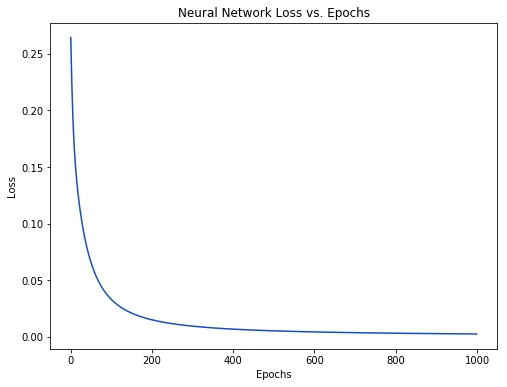
We can now use the network to predict genders:

In [5]:
# Make some predictions
emily = np.array([-7, -3]) # 128 pounds, 63 inches
frank = np.array([20, 2])  # 155 pounds, 68 inches
print("Emily: %.3f" % network.feedforward(emily)) # 0.951 - F
print("Frank: %.3f" % network.feedforward(frank)) # 0.039 - M

Emily: 0.969
Frank: 0.038


**Summary**

A quick recap of what we did:

1. Introduced neurons, the building blocks of neural networks.
2. Used the sigmoid activation function in our neurons.
3. Saw that neural networks are just neurons connected together.
4. Created a dataset with Weight and Height as inputs (or features) and Gender as the output (or label).
5. Learned about loss functions and the mean squared error (MSE) loss.
6. Realized that training a network is just minimizing its loss.
7. Used backpropagation to calculate partial derivatives.
8. Used stochastic gradient descent (SGD) to train our network.